# V3-Style Analysis on 2026-02-21 Data

### Data Format
- Single CSV with interleaved Gyroscope + Accelerometer readings
- Columns: Time, SensorType, Value1(x), Value2(y), Value3(z), Latitude, Longitude, Speed, Pothole
- **No GPS** (Latitude/Longitude all empty) → timeline plot instead of map
- **Speed all 0** → no speed filtering possible
- Accelerometer Z mean ≈ 9.69 m/s² → includes gravity → this IS TotalAcceleration

### Pipeline
1. Parse & separate Gyroscope / Accelerometer data
2. Compute TotalAcceleration magnitude
3. V3-style anomaly detection on Z-axis (threshold-based, since no speed for Prophet regressor)
4. Hybrid classification (gyro + accel features)
5. Timeline visualization with event markers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# ── Load data ──
raw = pd.read_csv('../2026-02-21.csv')
print(f'Total rows: {len(raw):,}')
print(f'Sensor types: {raw["SensorType"].value_counts().to_dict()}')
print(f'Time range: {raw["Time"].iloc[0]} → {raw["Time"].iloc[-1]}')
print(f'GPS available: {raw["Latitude"].notna().any()}')
print(f'Pothole labels: {(raw["Pothole"]==1).sum()} rows')

Total rows: 221,266
Sensor types: {'Gyroscope': 110652, 'Accelerometer': 110614}
Time range: 19:05:15.522 → 20:02:02.845
GPS available: False
Pothole labels: 2006 rows


In [2]:
# ── 1. Parse timestamps & separate sensors ──

# Convert Time to seconds elapsed
def time_to_seconds(t_str):
    parts = t_str.split(':')
    h, m = int(parts[0]), int(parts[1])
    s = float(parts[2])
    return h * 3600 + m * 60 + s

raw['seconds_abs'] = raw['Time'].apply(time_to_seconds)
raw['seconds_elapsed'] = raw['seconds_abs'] - raw['seconds_abs'].iloc[0]

# Separate sensors
accel = raw[raw['SensorType'] == 'Accelerometer'].copy()
gyro = raw[raw['SensorType'] == 'Gyroscope'].copy()

# Rename columns to match our A-F format
accel = accel.rename(columns={'Value1': 'x', 'Value2': 'y', 'Value3': 'z'})
gyro = gyro.rename(columns={'Value1': 'x', 'Value2': 'y', 'Value3': 'z'})

# Drop duplicates (many repeated timestamps in this data)
accel = accel.drop_duplicates(subset=['seconds_elapsed', 'x', 'y', 'z']).reset_index(drop=True)
gyro = gyro.drop_duplicates(subset=['seconds_elapsed', 'x', 'y', 'z']).reset_index(drop=True)

print(f'Accel after dedup: {len(accel):,} rows')
print(f'Gyro after dedup:  {len(gyro):,} rows')
print(f'Duration: {accel["seconds_elapsed"].max():.1f} seconds ({accel["seconds_elapsed"].max()/60:.1f} min)')
print(f'\nAccel sample rate: ~{len(accel)/accel["seconds_elapsed"].max():.0f} Hz')
print(f'Gyro sample rate:  ~{len(gyro)/gyro["seconds_elapsed"].max():.0f} Hz')

# Compute TotalAcceleration = the accel data itself (already includes gravity)
# Also compute magnitude
accel['magnitude'] = np.sqrt(accel['x']**2 + accel['y']**2 + accel['z']**2)
gyro['magnitude'] = np.sqrt(gyro['x']**2 + gyro['y']**2 + gyro['z']**2)

print(f'\nAccel Z stats: mean={accel["z"].mean():.2f}, std={accel["z"].std():.2f}, '
      f'min={accel["z"].min():.2f}, max={accel["z"].max():.2f}')
print(f'Gyro magnitude stats: mean={gyro["magnitude"].mean():.3f}, '
      f'max={gyro["magnitude"].max():.3f}')

Accel after dedup: 110,321 rows
Gyro after dedup:  110,417 rows
Duration: 3407.3 seconds (56.8 min)

Accel sample rate: ~32 Hz
Gyro sample rate:  ~32 Hz

Accel Z stats: mean=9.69, std=0.74, min=-6.50, max=37.40
Gyro magnitude stats: mean=0.035, max=5.700


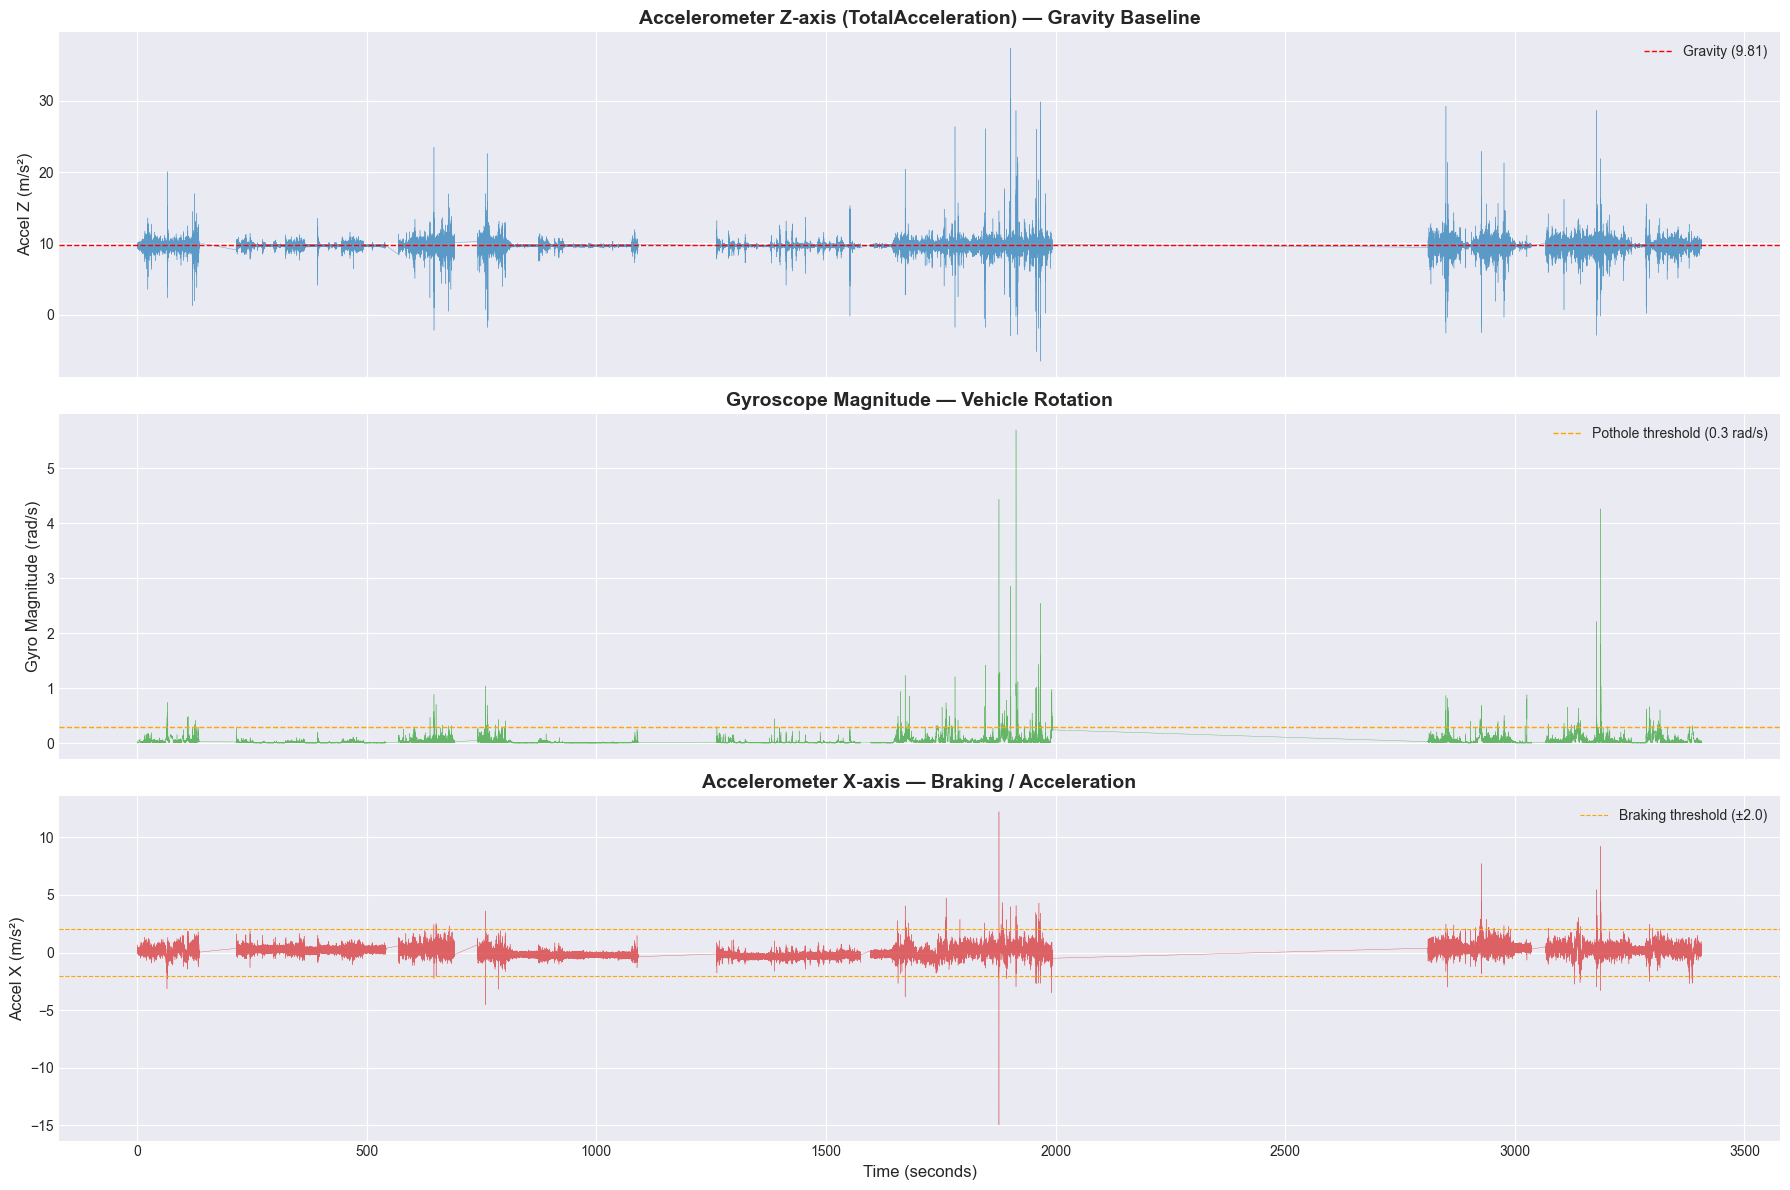

In [3]:
# ── 2. Visualize raw sensor data ──
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

t = accel['seconds_elapsed'].values

# Z-axis (primary pothole signal)
ax = axes[0]
ax.plot(t, accel['z'].values, lw=0.3, color='tab:blue', alpha=0.7)
ax.axhline(9.81, color='red', ls='--', lw=1, label='Gravity (9.81)')
ax.set_ylabel('Accel Z (m/s²)', fontsize=12)
ax.set_title('Accelerometer Z-axis (TotalAcceleration) — Gravity Baseline', fontsize=14, fontweight='bold')
ax.legend()

# Gyroscope magnitude
ax = axes[1]
gt = gyro['seconds_elapsed'].values
ax.plot(gt, gyro['magnitude'].values, lw=0.3, color='tab:green', alpha=0.7)
ax.axhline(0.3, color='orange', ls='--', lw=1, label='Pothole threshold (0.3 rad/s)')
ax.set_ylabel('Gyro Magnitude (rad/s)', fontsize=12)
ax.set_title('Gyroscope Magnitude — Vehicle Rotation', fontsize=14, fontweight='bold')
ax.legend()

# Accel X (braking/acceleration)
ax = axes[2]
ax.plot(t, accel['x'].values, lw=0.3, color='tab:red', alpha=0.7)
ax.axhline(2.0, color='orange', ls='--', lw=0.8, label='Braking threshold (±2.0)')
ax.axhline(-2.0, color='orange', ls='--', lw=0.8)
ax.set_ylabel('Accel X (m/s²)', fontsize=12)
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_title('Accelerometer X-axis — Braking / Acceleration', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

## 3. V3-Style Anomaly Detection

Since there is no GPS speed data, we cannot use Prophet with speed as a regressor.  
Instead, we use a **rolling statistics approach** (similar to V2's mean + k×std):

1. Compute a rolling baseline for Z-axis using a 10-second window
2. Flag anomalies where Z deviates more than 2× the rolling std from the rolling mean
3. Group contiguous anomaly samples into segments
4. Extract V3-style features per segment
5. Classify using the same hybrid rules

In [4]:
# ── 3a. Rolling baseline anomaly detection on Z-axis ──
WINDOW_SAMPLES = 500   # ~10 seconds at ~50Hz
K_THRESHOLD = 2.5      # flag if Z deviates more than 2.5× rolling std
MIN_SEG_SAMPLES = 3    # minimum samples to form a segment

z = accel['z'].values.astype(float)
t = accel['seconds_elapsed'].values.astype(float)

# Rolling mean and std
z_series = pd.Series(z)
roll_mean = z_series.rolling(WINDOW_SAMPLES, center=True, min_periods=50).mean().values
roll_std = z_series.rolling(WINDOW_SAMPLES, center=True, min_periods=50).std().values

# Fill edges with global stats
global_mean = np.nanmean(roll_mean)
global_std = np.nanmean(roll_std)
roll_mean = np.where(np.isnan(roll_mean), global_mean, roll_mean)
roll_std = np.where(np.isnan(roll_std), global_std, roll_std)

# Upper and lower bounds
upper = roll_mean + K_THRESHOLD * roll_std
lower = roll_mean - K_THRESHOLD * roll_std

# Flag anomalies
is_anomaly = (z < lower) | (z > upper)
print(f'Anomaly samples: {is_anomaly.sum()} / {len(z)} ({is_anomaly.mean()*100:.1f}%)')

# ── Group contiguous anomalies into segments ──
segments = []
in_seg = False
seg_start = 0

for i in range(len(is_anomaly)):
    if is_anomaly[i] and not in_seg:
        seg_start = i
        in_seg = True
    elif not is_anomaly[i] and in_seg:
        if i - seg_start >= MIN_SEG_SAMPLES:
            segments.append((seg_start, i - 1))
        in_seg = False

if in_seg and len(z) - seg_start >= MIN_SEG_SAMPLES:
    segments.append((seg_start, len(z) - 1))

print(f'Anomaly segments: {len(segments)}')
if len(segments) > 0:
    durations = [t[e] - t[s] for s, e in segments]
    print(f'Segment durations: min={min(durations):.3f}s, max={max(durations):.3f}s, median={np.median(durations):.3f}s')

Anomaly samples: 2375 / 110321 (2.2%)
Anomaly segments: 148
Segment durations: min=0.002s, max=0.235s, median=0.045s


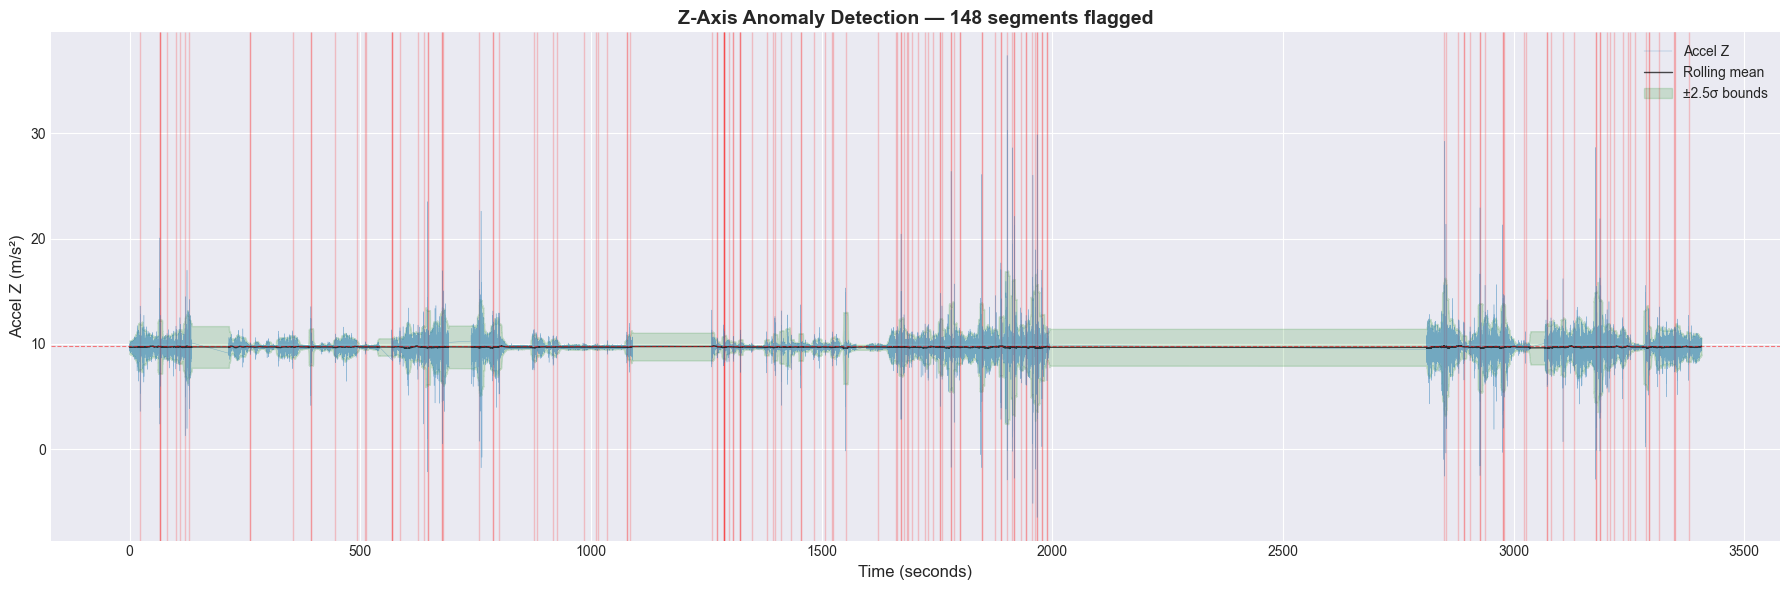

In [5]:
# ── 3b. Visualize anomaly detection ──
fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(t, z, lw=0.3, color='tab:blue', alpha=0.5, label='Accel Z')
ax.plot(t, roll_mean, lw=1, color='black', alpha=0.7, label='Rolling mean')
ax.fill_between(t, lower, upper, alpha=0.15, color='green', label=f'±{K_THRESHOLD}σ bounds')
ax.axhline(9.81, color='red', ls='--', lw=0.8, alpha=0.5)

# Highlight anomaly segments
for s, e in segments:
    ax.axvspan(t[s], t[e], alpha=0.2, color='red')

ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Accel Z (m/s²)', fontsize=12)
ax.set_title(f'Z-Axis Anomaly Detection — {len(segments)} segments flagged', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Feature Extraction & Classification

For each detected anomaly segment, extract V3-style features:
- **Z-axis**: dip/bump magnitude, total deviation from gravity
- **Gyroscope**: peak and RMS magnitude
- **X-axis**: braking/acceleration detection
- **Temporal context**: braking before/after

In [6]:
# ── 4a. Feature extraction per segment ──
GRAVITY = 9.81

# Build lookup arrays for gyro (interpolated to accel timestamps)
gyro_t = gyro['seconds_elapsed'].values
gyro_x = gyro['x'].values
gyro_y = gyro['y'].values
gyro_z_vals = gyro['z'].values
gyro_mag = gyro['magnitude'].values

accel_x = accel['x'].values
accel_t = accel['seconds_elapsed'].values

events = []

for seg_idx, (s, e) in enumerate(segments):
    t_start = t[s]
    t_end = t[e]
    duration = t_end - t_start
    
    # Z-axis features
    z_seg = z[s:e+1]
    z_min = z_seg.min()
    z_max = z_seg.max()
    z_mean = z_seg.mean()
    z_std = z_seg.std() if len(z_seg) > 1 else 0.0
    
    dip_magnitude = max(0, GRAVITY - z_min)      # how far below gravity
    bump_magnitude = max(0, z_max - GRAVITY)      # how far above gravity
    is_dip = dip_magnitude > bump_magnitude
    total_z_dev = max(abs(z_min - GRAVITY), abs(z_max - GRAVITY))
    
    # Gyro features (find gyro samples in this time window)
    g_mask = (gyro_t >= t_start - 0.05) & (gyro_t <= t_end + 0.05)
    if g_mask.sum() > 0:
        g_mags = gyro_mag[g_mask]
        gyro_peak = float(g_mags.max())
        gyro_rms = float(g_mags.mean())
    else:
        gyro_peak = gyro_rms = 0.0
    
    # Accel X features (braking/acceleration)
    ax_seg = accel_x[s:e+1]
    accel_x_min = float(ax_seg.min())
    accel_x_max = float(ax_seg.max())
    accel_x_peak = float(np.abs(ax_seg).max())
    
    # Braking context
    pre_mask = (accel_t >= t_start - 1.0) & (accel_t < t_start)
    braking_before = bool(pre_mask.sum() > 0 and accel_x[pre_mask].min() < -1.5)
    post_mask = (accel_t > t_end) & (accel_t <= t_end + 1.0)
    braking_after = bool(post_mask.sum() > 0 and accel_x[post_mask].min() < -1.5)
    
    events.append({
        'seg_idx': seg_idx,
        't_start': t_start,
        't_end': t_end,
        't_mid': (t_start + t_end) / 2,
        'duration': duration,
        'n_samples': e - s + 1,
        'z_min': z_min, 'z_max': z_max, 'z_mean': z_mean, 'z_std': z_std,
        'dip_magnitude': dip_magnitude,
        'bump_magnitude': bump_magnitude,
        'is_dip': is_dip,
        'total_z_dev': total_z_dev,
        'gyro_peak': gyro_peak,
        'gyro_rms': gyro_rms,
        'accel_x_min': accel_x_min,
        'accel_x_max': accel_x_max,
        'accel_x_peak': accel_x_peak,
        'braking_before': braking_before,
        'braking_after': braking_after,
    })

events_df = pd.DataFrame(events)
print(f'Extracted features for {len(events_df)} segments')
print(f'\nFeature summary:')
print(f'  Dip magnitude:  min={events_df["dip_magnitude"].min():.2f}, '
      f'max={events_df["dip_magnitude"].max():.2f}, mean={events_df["dip_magnitude"].mean():.2f}')
print(f'  Bump magnitude: min={events_df["bump_magnitude"].min():.2f}, '
      f'max={events_df["bump_magnitude"].max():.2f}, mean={events_df["bump_magnitude"].mean():.2f}')
print(f'  Gyro peak:      min={events_df["gyro_peak"].min():.3f}, '
      f'max={events_df["gyro_peak"].max():.3f}, mean={events_df["gyro_peak"].mean():.3f}')
print(f'  Accel X peak:   min={events_df["accel_x_peak"].min():.2f}, '
      f'max={events_df["accel_x_peak"].max():.2f}, mean={events_df["accel_x_peak"].mean():.2f}')

Extracted features for 148 segments

Feature summary:
  Dip magnitude:  min=0.00, max=16.31, mean=3.74
  Bump magnitude: min=0.00, max=27.59, mean=3.85
  Gyro peak:      min=0.007, max=5.700, mean=0.396
  Accel X peak:   min=0.07, max=7.73, mean=1.14


In [7]:
# ── 4b. V3-style classification ──

def classify_event(row):
    """
    V3-style classification using physics rules.
    Same logic as the hybrid Pawar+V3 but without Pawar model (no windowed features here).
    Returns (event_type, severity, confidence).
    """
    dip_mag  = row['dip_magnitude']
    bump_mag = row['bump_magnitude']
    tz_dev   = row['total_z_dev']
    g_peak   = row['gyro_peak']
    g_rms    = row['gyro_rms']
    x_min    = row['accel_x_min']
    x_max    = row['accel_x_max']
    x_peak   = row['accel_x_peak']
    dur      = row['duration']
    brk_bef  = row['braking_before']
    brk_aft  = row['braking_after']
    
    has_dip  = dip_mag > 0.5
    has_bump = bump_mag > 0.5

    # 1. HARD BRAKING / ACCELERATION
    if x_peak > 2.0 and g_peak < 0.3 and tz_dev < 2.0:
        severity = min(10, x_peak * 1.5)
        if x_min < -2.5:
            return 'Hard Braking', severity, 0.80
        elif x_max > 2.5:
            return 'Acceleration', severity, 0.75
        lbl = 'Hard Braking' if abs(x_min) > x_max else 'Acceleration'
        return lbl, severity, 0.70

    if brk_bef and g_peak < 0.3 and tz_dev < 2.0:
        severity = min(10, x_peak * 1.2)
        return 'Hard Braking', severity, 0.65

    # 2. ROAD BUMP: Z went UP only
    if has_bump and not has_dip:
        severity = min(10, bump_mag * 1.5)
        if dur > 0.15 and bump_mag > 2.0:
            return 'Speed Bump', severity, 0.70
        return 'Road Bump', severity, 0.50

    # 3. SPEED BUMP: both dip AND bump
    if has_dip and has_bump and g_peak < 0.8:
        total_osc = dip_mag + bump_mag
        if total_osc > 3.0 or (bump_mag > dip_mag * 0.5 and bump_mag > 1.0):
            severity = min(10, total_osc * 0.8)
            return 'Speed Bump', severity, 0.65

    # 4. POTHOLE: Z dip + gyro confirms
    if has_dip:
        severity = min(10, dip_mag * 1.2 + g_peak * 2.0)
        if g_peak > 0.3:
            confidence = min(0.95, 0.55 + dip_mag * 0.05 + g_peak * 0.15)
            if brk_aft:
                confidence = min(1.0, confidence + 0.05)
            return 'Pothole', severity, confidence
        if dip_mag > 3.0:
            return 'Pothole', severity, 0.55
        if dip_mag > 1.5 and g_peak > 0.15:
            return 'Pothole', severity, 0.50
        return 'Rough Patch', min(5, dip_mag * 0.8), 0.30

    # 5. MINOR ANOMALY
    severity = min(4, tz_dev * 0.5)
    return 'Minor Anomaly', severity, 0.20


# Apply
classified = events_df.apply(classify_event, axis=1, result_type='expand')
events_df['event_type'] = classified[0]
events_df['severity'] = classified[1].astype('float32')
events_df['confidence'] = classified[2].astype('float32')

# Filter out minor anomalies for the main view
meaningful = events_df[events_df['event_type'] != 'Minor Anomaly'].copy()

print(f'\nAll {len(events_df)} events:')
print(events_df['event_type'].value_counts().to_string())
print(f'\n{len(meaningful)} meaningful events (excluding Minor Anomaly):')
print(meaningful['event_type'].value_counts().to_string())

# Stats per type
for etype in meaningful['event_type'].unique():
    sub = meaningful[meaningful['event_type'] == etype]
    print(f'\n  {etype} ({len(sub)}):  '
          f'avg sev={sub["severity"].mean():.1f}, '
          f'avg conf={sub["confidence"].mean():.2f}, '
          f'avg gyro={sub["gyro_peak"].mean():.3f}, '
          f'avg dip={sub["dip_magnitude"].mean():.2f}')


All 148 events:
event_type
Speed Bump       76
Pothole          29
Rough Patch      21
Road Bump        15
Minor Anomaly     6
Hard Braking      1

142 meaningful events (excluding Minor Anomaly):
event_type
Speed Bump      76
Pothole         29
Rough Patch     21
Road Bump       15
Hard Braking     1

  Speed Bump (76):  avg sev=5.5, avg conf=0.65, avg gyro=0.226, avg dip=4.15

  Rough Patch (21):  avg sev=0.8, avg conf=0.30, avg gyro=0.036, avg dip=1.02

  Road Bump (15):  avg sev=3.7, avg conf=0.50, avg gyro=0.204, avg dip=0.00

  Pothole (29):  avg sev=8.2, avg conf=0.85, avg gyro=1.287, avg dip=7.35

  Hard Braking (1):  avg sev=0.7, avg conf=0.65, avg gyro=0.295, avg dip=1.80


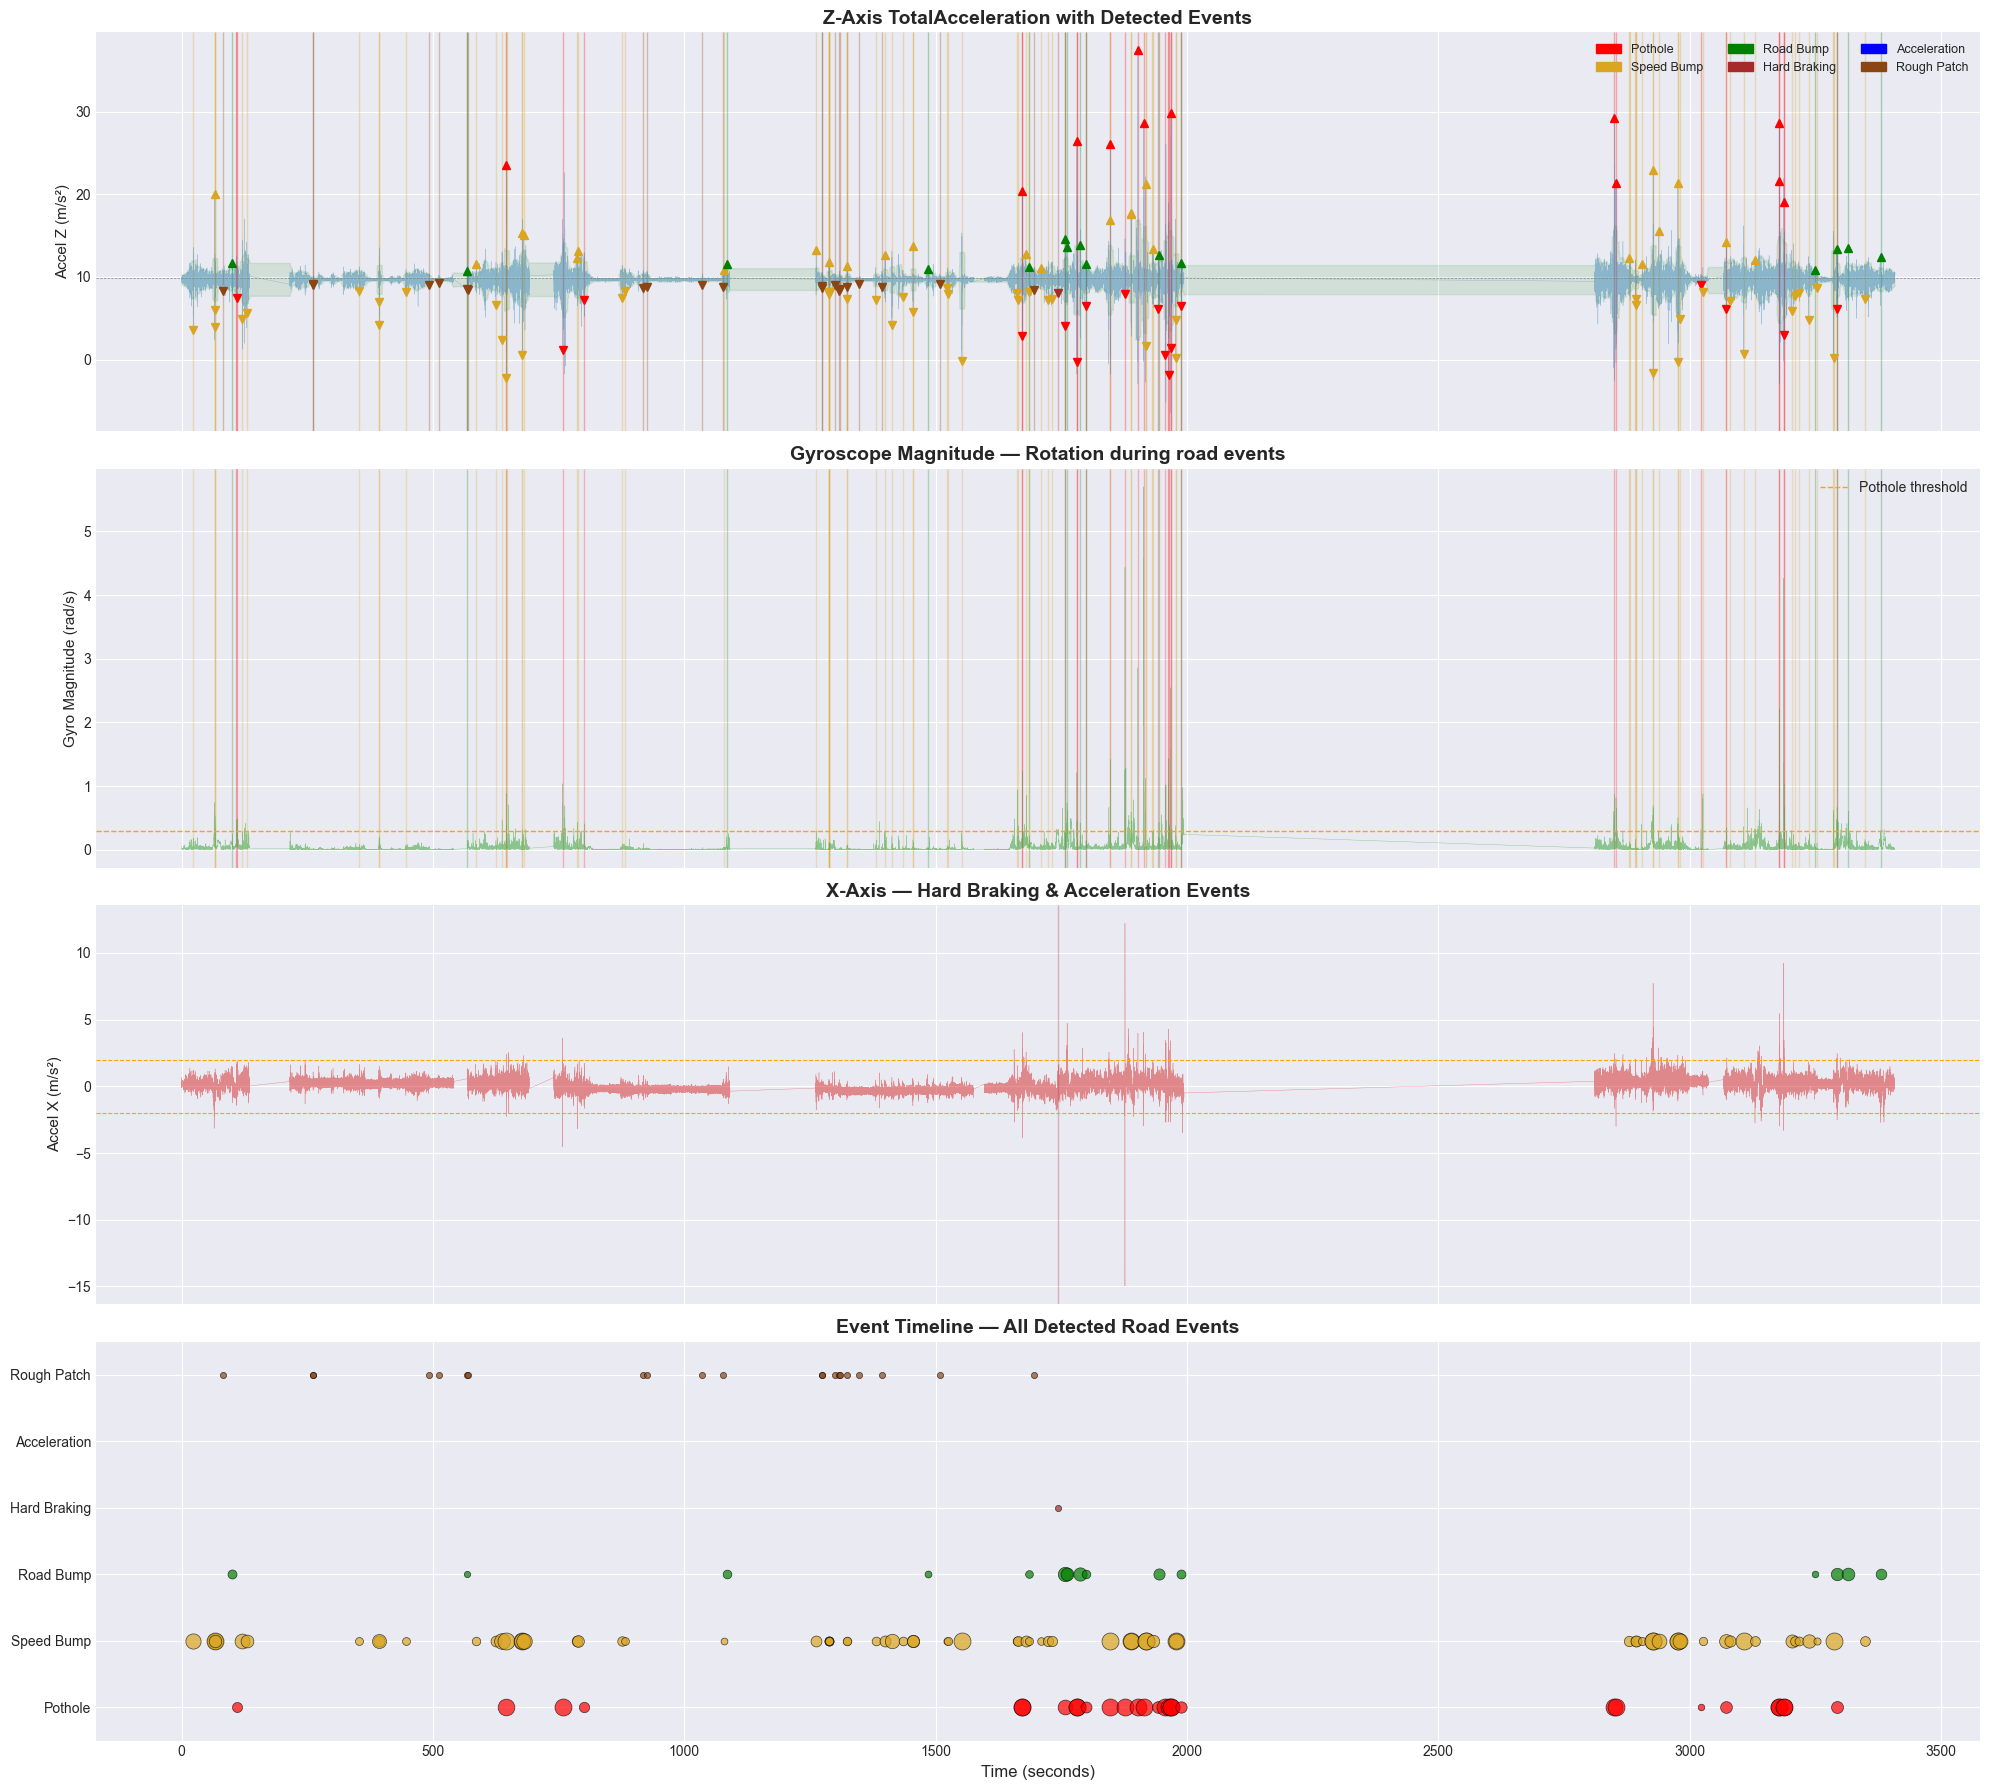

Saved: analysis_2026_02_21_timeline.png


In [8]:
# ── 5. Timeline Plot — All Events ──

color_map = {
    'Pothole': 'red',
    'Road Bump': 'green',
    'Speed Bump': '#DAA520',
    'Hard Braking': 'brown',
    'Rough Patch': '#8B4513',
    'Acceleration': 'blue',
    'Minor Anomaly': 'gray',
}

fig, axes = plt.subplots(4, 1, figsize=(20, 18), sharex=True)

# ── Panel 1: Z-axis with events ──
ax = axes[0]
ax.plot(t, z, lw=0.3, color='tab:blue', alpha=0.4, label='Accel Z')
ax.fill_between(t, lower, upper, alpha=0.1, color='green')
ax.axhline(9.81, color='gray', ls='--', lw=0.5)

for _, ev in meaningful.iterrows():
    color = color_map.get(ev['event_type'], 'gray')
    ax.axvspan(ev['t_start'], ev['t_end'], alpha=0.3, color=color)
    ax.plot(ev['t_mid'], ev['z_min'] if ev['is_dip'] else ev['z_max'],
            'v' if ev['is_dip'] else '^', color=color, markersize=6)

ax.set_ylabel('Accel Z (m/s²)', fontsize=11)
ax.set_title('Z-Axis TotalAcceleration with Detected Events', fontsize=14, fontweight='bold')

# ── Panel 2: Gyroscope magnitude ──
ax = axes[1]
ax.plot(gyro_t, gyro_mag, lw=0.3, color='tab:green', alpha=0.5)
ax.axhline(0.3, color='orange', ls='--', lw=1, label='Pothole threshold')

for _, ev in meaningful.iterrows():
    if ev['event_type'] in ['Pothole', 'Speed Bump', 'Road Bump']:
        color = color_map.get(ev['event_type'], 'gray')
        ax.axvspan(ev['t_start'], ev['t_end'], alpha=0.25, color=color)

ax.set_ylabel('Gyro Magnitude (rad/s)', fontsize=11)
ax.set_title('Gyroscope Magnitude — Rotation during road events', fontsize=14, fontweight='bold')
ax.legend()

# ── Panel 3: X-axis (braking) ──
ax = axes[2]
ax.plot(t, accel_x, lw=0.3, color='tab:red', alpha=0.5)
ax.axhline(2.0, color='orange', ls='--', lw=0.8)
ax.axhline(-2.0, color='orange', ls='--', lw=0.8)

for _, ev in meaningful.iterrows():
    if ev['event_type'] in ['Hard Braking', 'Acceleration']:
        color = color_map.get(ev['event_type'], 'gray')
        ax.axvspan(ev['t_start'], ev['t_end'], alpha=0.3, color=color)

ax.set_ylabel('Accel X (m/s²)', fontsize=11)
ax.set_title('X-Axis — Hard Braking & Acceleration Events', fontsize=14, fontweight='bold')

# ── Panel 4: Event timeline (strip chart) ──
ax = axes[3]
event_types_sorted = ['Pothole', 'Speed Bump', 'Road Bump', 'Hard Braking',
                       'Acceleration', 'Rough Patch']
y_map = {etype: i for i, etype in enumerate(event_types_sorted)}

for _, ev in meaningful.iterrows():
    etype = ev['event_type']
    if etype not in y_map:
        continue
    color = color_map.get(etype, 'gray')
    y_pos = y_map[etype]
    size = max(20, ev['severity'] * 15)
    ax.scatter(ev['t_mid'], y_pos, c=color, s=size, alpha=0.7,
              edgecolors='black', linewidths=0.5)

ax.set_yticks(range(len(event_types_sorted)))
ax.set_yticklabels(event_types_sorted)
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_title('Event Timeline — All Detected Road Events', fontsize=14, fontweight='bold')
ax.set_ylim(-0.5, len(event_types_sorted) - 0.5)

# Legend
patches = [mpatches.Patch(color=color_map[e], label=e) for e in event_types_sorted if e in color_map]
axes[0].legend(handles=patches, loc='upper right', fontsize=9, ncol=3)

plt.tight_layout()
plt.savefig('analysis_2026_02_21_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: analysis_2026_02_21_timeline.png')

In [9]:
# ── 6. Summary & Export ──

# Save events CSV
export_cols = ['t_start', 't_end', 't_mid', 'duration', 'event_type', 'severity',
               'confidence', 'dip_magnitude', 'bump_magnitude', 'gyro_peak',
               'accel_x_peak', 'total_z_dev']
meaningful[export_cols].to_csv('events_2026_02_21.csv', index=False)
print(f'Exported {len(meaningful)} events to events_2026_02_21.csv')

# Summary
print(f'\n{"="*60}')
print(f'V3-STYLE ANALYSIS SUMMARY — 2026-02-21')
print(f'{"="*60}')
print(f'Recording duration: {t[-1]:.0f}s ({t[-1]/60:.1f} min)')
print(f'Accel samples: {len(accel):,} | Gyro samples: {len(gyro):,}')
print(f'Anomaly segments: {len(events_df)}')
print(f'Meaningful events: {len(meaningful)}')
print(f'\nEvent breakdown:')
for etype in meaningful['event_type'].value_counts().index:
    sub = meaningful[meaningful['event_type'] == etype]
    print(f'  {etype:20s}: {len(sub):3d}  avg severity={sub["severity"].mean():.1f}/10  '
          f'avg confidence={sub["confidence"].mean():.0%}')

print(f'\n{"─"*60}')
print(f'NOTE: No GPS data available in this recording.')
print(f'      Map visualization not possible — see timeline plot above.')
print(f'      Speed was 0 throughout — no speed-based filtering applied.')

Exported 142 events to events_2026_02_21.csv

V3-STYLE ANALYSIS SUMMARY — 2026-02-21
Recording duration: 3407s (56.8 min)
Accel samples: 110,321 | Gyro samples: 110,417
Anomaly segments: 148
Meaningful events: 142

Event breakdown:
  Speed Bump          :  76  avg severity=5.5/10  avg confidence=65%
  Pothole             :  29  avg severity=8.2/10  avg confidence=85%
  Rough Patch         :  21  avg severity=0.8/10  avg confidence=30%
  Road Bump           :  15  avg severity=3.7/10  avg confidence=50%
  Hard Braking        :   1  avg severity=0.7/10  avg confidence=65%

────────────────────────────────────────────────────────────
NOTE: No GPS data available in this recording.
      Map visualization not possible — see timeline plot above.
      Speed was 0 throughout — no speed-based filtering applied.


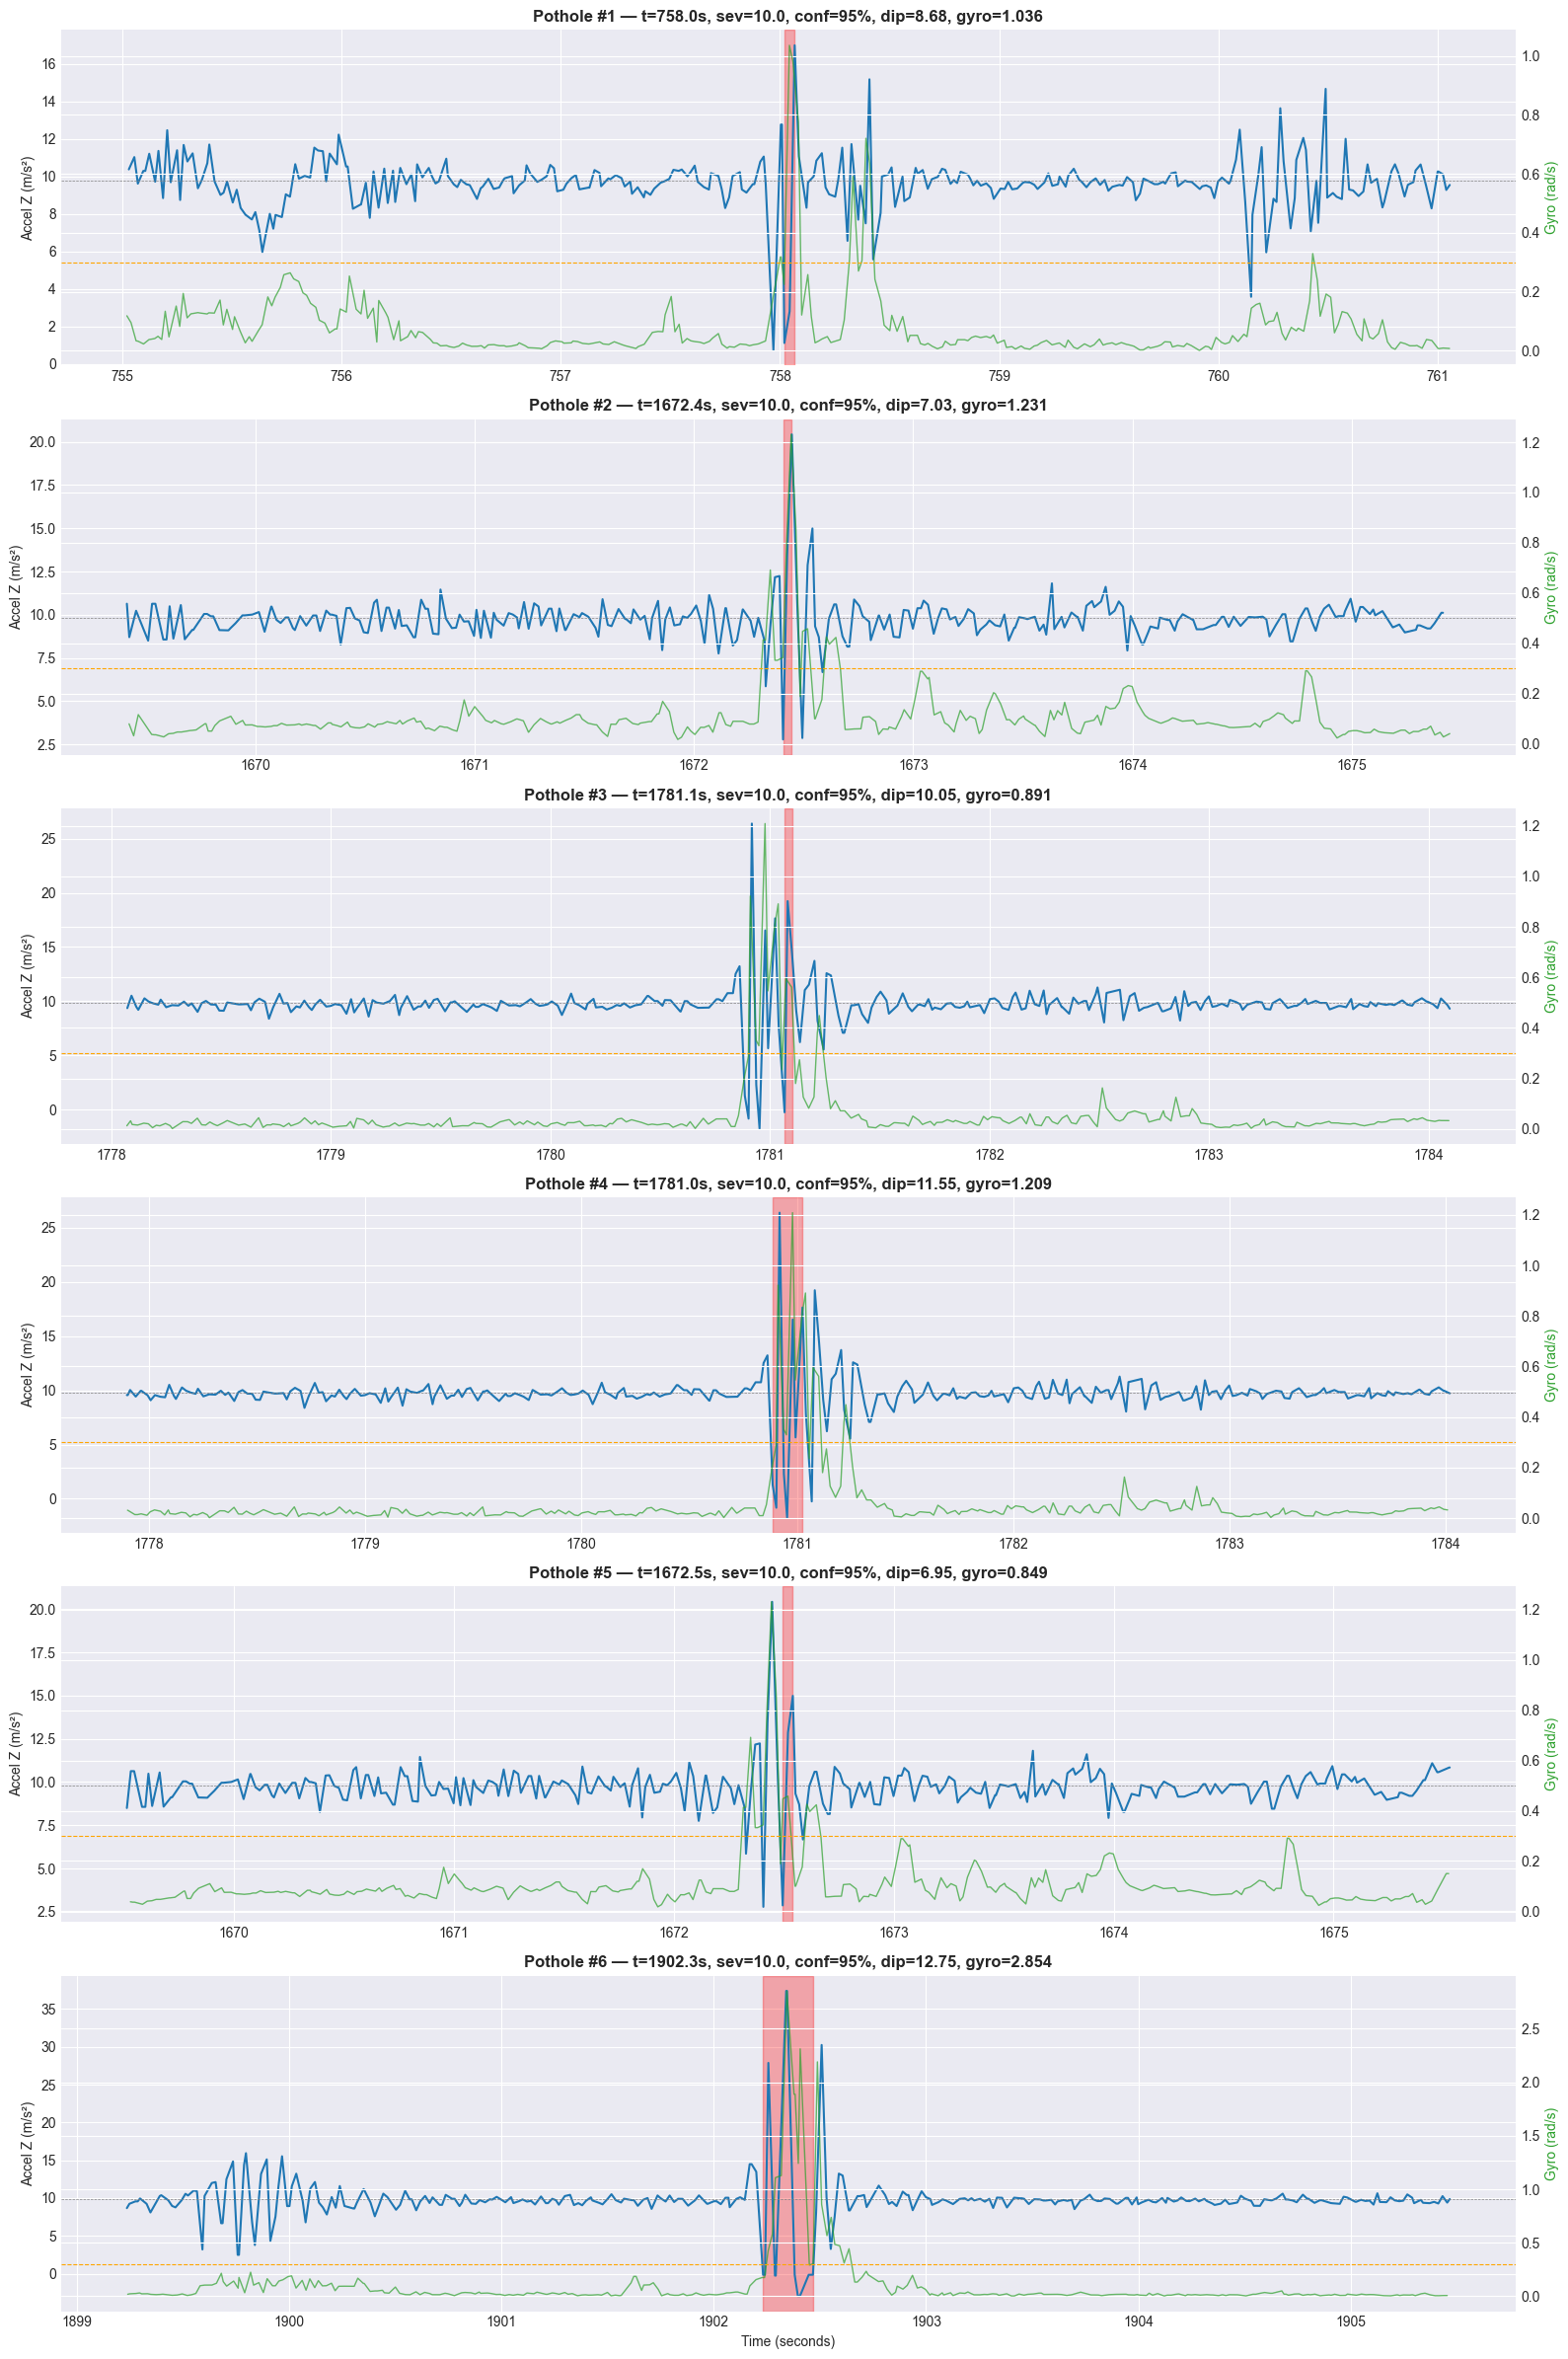

Saved: potholes_2026_02_21_zoom.png


In [10]:
# ── 7. Zoomed-in views of detected potholes ──

potholes = meaningful[meaningful['event_type'] == 'Pothole'].sort_values('severity', ascending=False)

if len(potholes) > 0:
    n_show = min(6, len(potholes))
    fig, axes = plt.subplots(n_show, 1, figsize=(16, 4 * n_show))
    if n_show == 1:
        axes = [axes]
    
    for idx, (_, ev) in enumerate(potholes.head(n_show).iterrows()):
        ax = axes[idx]
        # Show ±3 seconds around the event
        t_lo = ev['t_start'] - 3
        t_hi = ev['t_end'] + 3
        mask_a = (accel_t >= t_lo) & (accel_t <= t_hi)
        mask_g = (gyro_t >= t_lo) & (gyro_t <= t_hi)
        
        ax.plot(accel_t[mask_a], z[mask_a], lw=1.5, color='tab:blue', label='Accel Z')
        ax.axhline(9.81, color='gray', ls='--', lw=0.5)
        ax.axvspan(ev['t_start'], ev['t_end'], alpha=0.3, color='red')
        
        # Overlay gyro on twin axis
        ax2 = ax.twinx()
        ax2.plot(gyro_t[mask_g], gyro_mag[mask_g], lw=1, color='tab:green', alpha=0.7, label='Gyro mag')
        ax2.axhline(0.3, color='orange', ls='--', lw=0.8)
        ax2.set_ylabel('Gyro (rad/s)', color='tab:green')
        
        ax.set_ylabel('Accel Z (m/s²)')
        ax.set_title(f'Pothole #{idx+1} — t={ev["t_mid"]:.1f}s, '
                     f'sev={ev["severity"]:.1f}, conf={ev["confidence"]:.0%}, '
                     f'dip={ev["dip_magnitude"]:.2f}, gyro={ev["gyro_peak"]:.3f}',
                     fontsize=12, fontweight='bold')
    
    axes[-1].set_xlabel('Time (seconds)')
    plt.tight_layout()
    plt.savefig('potholes_2026_02_21_zoom.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: potholes_2026_02_21_zoom.png')
else:
    print('No potholes detected.')